# Pandas 실습

### 1. 실습 데이터 준비

- '서울시 지하철호선별 역별 승하차 인원'

In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np

In [2]:
# 데이터 로드
df = pd.read_csv('data/CARD_SUBWAY_MONTH_202605.csv')

In [4]:
# 데이터 로드
df = pd.read_csv('data/CARD_SUBWAY_MONTH_202605.csv', index_col = False)

In [5]:
df.head()

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
0,20260501,5호선,방이,5527,5357,20260504
1,20260501,5호선,둔촌동,10441,9979,20260504
2,20260501,5호선,상일동,10541,9932,20260504
3,20260501,5호선,고덕,7456,7257,20260504
4,20260501,5호선,명일,6377,6251,20260504


### 2. 데이터 탐색

In [9]:
# 상위 5개의 데이터를 조회
df.head()

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
0,20260501,5호선,방이,5527,5357,20260504
1,20260501,5호선,둔촌동,10441,9979,20260504
2,20260501,5호선,상일동,10541,9932,20260504
3,20260501,5호선,고덕,7456,7257,20260504
4,20260501,5호선,명일,6377,6251,20260504


In [14]:
# 데이터프레임의 형태를 확인
df.shape

(19131, 6)

In [13]:
# 하위 데이터 10개를 조회
df.tail(10)

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
19121,20260531,8호선,문정,7350,7431,20260603
19122,20260531,8호선,장지,10401,9980,20260603
19123,20260531,8호선,복정,5988,5340,20260603
19124,20260531,8호선,산성,3611,3915,20260603
19125,20260531,8호선,남한산성입구(성남법원.검찰청),6905,6413,20260603
19126,20260531,8호선,단대오거리,6782,6559,20260603
19127,20260531,8호선,신흥,3732,3895,20260603
19128,20260531,8호선,수진,4223,3812,20260603
19129,20260531,8호선,모란,3406,2806,20260603
19130,20260531,8호선,남위례,4515,4530,20260603


In [15]:
# 데이터의 사분위수, 표준편차, 분산 등 통계지표를 조회
df.describe()

,사용일자,승차총승객수,하차총승객수,등록일자
count,1.913100e+04,19131.000000,19131.000000,1.913100e+04
mean,2.026052e+07,11811.350740,11759.563640,2.026053e+07
std,8.944833e+00,11836.994181,12011.261965,2.614125e+01
min,2.026050e+07,1.000000,0.000000,2.026050e+07
25%,2.026051e+07,4125.000000,4022.000000,2.026051e+07
50%,2.026052e+07,8396.000000,8135.000000,2.026052e+07
75%,2.026052e+07,15701.500000,15507.500000,2.026053e+07
max,2.026053e+07,101927.000000,115875.000000,2.026060e+07


In [16]:
# 데이터의 데이터타입, 결측치등을 조회
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19131 entries, 0 to 19130
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   사용일자    19131 non-null  int64 
 1   노선명     19131 non-null  object
 2   역명      19131 non-null  object
 3   승차총승객수  19131 non-null  int64 
 4   하차총승객수  19131 non-null  int64 
 5   등록일자    19131 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 896.9+ KB


In [19]:
# '노선명' 컬럼이 가지고 있는 데이터 종류를 확인, 중복되지 않은 데이터 갯수와 확인
df['노선명'].nunique() #27
df['노선명'].unique() #27

array(['5호선', '4호선', '경의선', '3호선', '2호선', '1호선', '경인선', '경춘선', '공항철도 1호선',
       '안산선', '과천선', '분당선', '서해선', '수인선', '신림선', '우이신설선', '일산선', '장항선',
       '중앙선', '경원선', '경부선', '경강선', '9호선2~3단계', '9호선', '8호선', '7호선', '6호선'],
      dtype=object)

In [ ]:
# '역명' 컬럼이 가지고 있는 데이터 종류를 확인, 중복되지 않은 데이터 갯수와 확인
df['역명'].nunique() #27
df['역명'].unique() #27

In [22]:
# '범주형' - value_counts() : 몇번이나 반복(등장)하는가 확인
# '노선명' 컬럼이 가지고 있는 데이터 분포 확인
df['역명'].value_counts()

역명
서울역      155
공덕       124
김포공항     124
홍대입구      93
고속터미널     93
        ... 
남춘천       31
김유정       31
강촌        31
백양리       31
개롱        31
Name: count, Length: 528, dtype: int64

In [23]:
df['승차총승객수'].value_counts()

승차총승객수
1        49
2        45
5        20
4        19
3        18
         ..
30750     1
11124     1
33285     1
12135     1
6782      1
Name: count, Length: 13255, dtype: int64

### 3. 정렬

In [25]:
# '승차총승객수' 기준으로 데이터 정렬(내림차순)
df.sort_values(by=['승차총승객수'], ascending=False)

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
118,20260501,2호선,홍대입구,101927,115875,20260504
8668,20260515,2호선,잠실(송파구청),100436,98646,20260518
682,20260502,2호선,홍대입구,100394,111108,20260505
8674,20260515,2호선,강남,98157,96835,20260518
13541,20260522,1호선,서울역,97514,98036,20260525
...,...,...,...,...,...,...
7066,20260512,경의선,계양,1,0,20260515
15461,20260526,경원선,창동,1,0,20260529
7065,20260512,경의선,운천,1,3,20260515
16916,20260528,일산선,지축,1,0,20260531


### 4. 선택

In [26]:
df2 = df.set_index('사용일자')
df2

,노선명,역명,승차총승객수,하차총승객수,등록일자
사용일자,,,,,
20260501,5호선,방이,5527,5357,20260504
20260501,5호선,둔촌동,10441,9979,20260504
20260501,5호선,상일동,10541,9932,20260504
20260501,5호선,고덕,7456,7257,20260504
20260501,5호선,명일,6377,6251,20260504
...,...,...,...,...,...
20260531,8호선,단대오거리,6782,6559,20260603
20260531,8호선,신흥,3732,3895,20260603
20260531,8호선,수진,4223,3812,20260603


In [28]:
print(df.head(3))
print('-'*30)
print(df2.head(3))
      

       사용일자  노선명   역명  승차총승객수  하차총승객수      등록일자
0  20260501  5호선   방이    5527    5357  20260504
1  20260501  5호선  둔촌동   10441    9979  20260504
2  20260501  5호선  상일동   10541    9932  20260504
------------------------------
          노선명   역명  승차총승객수  하차총승객수      등록일자
사용일자                                        
20260501  5호선   방이    5527    5357  20260504
20260501  5호선  둔촌동   10441    9979  20260504
20260501  5호선  상일동   10541    9932  20260504


In [29]:
# 인덱스 검색 : loc, iloc
df2.iloc[1]

노선명            5호선
역명             둔촌동
승차총승객수       10441
하차총승객수        9979
등록일자      20260504
Name: 20260501, dtype: object

In [30]:
df2.head()

,노선명,역명,승차총승객수,하차총승객수,등록일자
사용일자,,,,,
20260501,5호선,방이,5527,5357,20260504
20260501,5호선,둔촌동,10441,9979,20260504
20260501,5호선,상일동,10541,9932,20260504
20260501,5호선,고덕,7456,7257,20260504
20260501,5호선,명일,6377,6251,20260504


In [31]:
# 20260510 일자 데이터 검색
df2.loc[20260510]

,노선명,역명,승차총승객수,하차총승객수,등록일자
사용일자,,,,,
20260510,7호선,태릉입구,6549,6519,20260513
20260510,5호선,신길,3197,3374,20260513
20260510,9호선,양천향교,5221,5473,20260513
20260510,9호선,가양,13415,13294,20260513
20260510,9호선,증미,3114,3300,20260513
...,...,...,...,...,...
20260510,중앙선,양평,3155,2873,20260513
20260510,중앙선,원덕,479,373,20260513
20260510,중앙선,용문,4829,4286,20260513


In [ ]:
# 일반 데이터 검색 : 팬시, 불린, query
# '노선명' 컬럼의 '2호선' 데이터 조회
# 불린 인덱싱 조건 : df2['노선명'] == '2호선'
df2[df2['노선명'] == '2호선']

In [36]:
# 일반 데이터 검색 : 팬시, 불린, query
# '노선명' 컬럼의 '2호선' 데이터 조회
# 불린 인덱싱 조건 : '노선명 == "2호선"'
df2.query('노선명 == "2호선"')

,노선명,역명,승차총승객수,하차총승객수,등록일자
사용일자,,,,,
20260501,2호선,용두(동대문구청),1980,1746,20260504
20260501,2호선,신정네거리,7710,7364,20260504
20260501,2호선,양천구청,4845,4751,20260504
20260501,2호선,도림천,814,803,20260504
20260501,2호선,신설동,3984,3453,20260504
...,...,...,...,...,...
20260531,2호선,신설동,3960,3664,20260603
20260531,2호선,도림천,910,1127,20260603
20260531,2호선,양천구청,3858,3948,20260603


In [41]:
# '승차총승객수' 이 50000명 이상인 '역명' 조회
# 볼린인덱싱 df2['승차총승객수'] >= 50000
df2[df2['승차총승객수'] >= 50000]['역명']
df2[df2['승차총승객수'] >= 50000]['역명'].unique()

array(['고속터미널', '홍대입구', '강남', '잠실(송파구청)', '성수', '서울역', '수원', '용산',
       '서울대입구(관악구청)', '선릉', '을지로입구', '구로디지털단지', '신도림', '신림', '삼성(무역센터)',
       '역삼', '가산디지털단지', '사당', '혜화', '종각'], dtype=object)

In [42]:
# '승차총승객수' 이 50000명 이상인 '역명' 조회
# 쿼리 : '승차총승객수 >= 50000'
df2.query('승차총승객수 >= 50000')['역명']

사용일자
20260501       고속터미널
20260501        홍대입구
20260501          강남
20260501    잠실(송파구청)
20260501          성수
              ...   
20260531          용산
20260531         서울역
20260531    잠실(송파구청)
20260531        홍대입구
20260531       고속터미널
Name: 역명, Length: 354, dtype: object

In [47]:
# '승차총승객수' 이 50000명 이상이고, '역명' 이름이 '강남인' 데이터 조회
df2[(df2['승차총승객수'] >= 50000) & (df2['역명'] == '강남')].count()

노선명       24
역명        24
승차총승객수    24
하차총승객수    24
등록일자      24
dtype: int64

In [50]:
# '승차총승객수' 이 50000명 이상이고, '역명' 이름이 '강남인' 데이터 조회
df2.query("승차총승객수 >= 50000 & 역명 == '강남'")
df2.query("승차총승객수 >= 50000 & 역명 == '강남'").count()

노선명       24
역명        24
승차총승객수    24
하차총승객수    24
등록일자      24
dtype: int64

In [51]:
# '승차총승객수' 컬럼의 최대값
df['승차총승객수'].max()

101927

In [52]:
# '승차총승객수' 컬럼의 최소값
df['승차총승객수'].min()

1

In [53]:
# '승차총승객수' 컬럼의 최대값, '하차총승객수' 컬럼의 최소값을 조회
df2.agg(
    {
        '승차총승객수': 'max',
        '하차총승객수': 'min'
    }
)

승차총승객수    101927
하차총승객수         0
dtype: int64

In [54]:
# '승차총승객수' '하차총승객수' 컬럼의 최대값을 조회
df[['승차총승객수', '하차총승객수']].max()

승차총승객수    101927
하차총승객수    115875
dtype: int64

In [56]:
# '승차총승객수' '하차총승객수' 컬럼의 최대값을 조회
df[['승차총승객수', '하차총승객수']].agg(['max', 'min', 'mean', 'median'])

,승차총승객수,하차총승객수
max,101927.00000,115875.00000
min,1.00000,0.00000
mean,11811.35074,11759.56364
median,8396.00000,8135.00000


## 5. 삭제

In [ ]:
# 행 기준으로 삭제, 0번지 행 삭제, df
df.drop(0)

In [ ]:
# 행 기준으로 삭제, 3, 5, 7 번지 행 삭제, df
df.drop([3, 5, 7])

In [ ]:
# '등록일자' 컬럼 삭제
df.drop('등록일자', axis=1)

In [62]:
# '등록일자', '역명' 컬럼 삭제
df.drop(['등록일자', '역명'], axis=1)

,사용일자,노선명,승차총승객수,하차총승객수
0,20260501,5호선,5527,5357
1,20260501,5호선,10441,9979
2,20260501,5호선,10541,9932
3,20260501,5호선,7456,7257
4,20260501,5호선,6377,6251
...,...,...,...,...
19126,20260531,8호선,6782,6559
19127,20260531,8호선,3732,3895
19128,20260531,8호선,4223,3812
19129,20260531,8호선,3406,2806


## 6. 연산

In [ ]:
# '승차총승객수' 컬럼에 10을 더하여, '승차총승객수_10' 컬럼을 추가
df['승차총승객수_10'] = df['승차총승객수'] + 10
df

In [ ]:
# '승차총승객수' - '하차총승색수' 결과를 '승하차총승객수' 컬럼으로 생성하여 추가
df['승하차총승객수'] = df['승차총승객수'] - df['하차총승객수']
df

In [ ]:
# '승차총승객수' + '하차총승색수' 결과를 '승하차총승객수합계' 컬럼으로 생성하여 추가
df['승하차총승객수합계'] = df['승차총승객수'] + df['하차총승객수']
df

In [68]:
# '승하차총승객수' 의 평균값, 중앙값
print(df['승하차총승객수'].mean())
print(df['승하차총승객수'].median())
df['승하차총승객수'].agg(['mean', 'median'])

51.78709947206105
97.0


mean      51.787099
median    97.000000
Name: 승하차총승객수, dtype: float64

In [68]:
# '승하차총승객수' 의 평균값, 중앙값
print(df['승하차총승객수'].mean())
print(df['승하차총승객수'].median())
df['승하차총승객수'].agg(['mean', 'median'])

51.78709947206105
97.0


mean      51.787099
median    97.000000
Name: 승하차총승객수, dtype: float64

In [72]:
# Index 재생성 후 df2에 반영, 기존 인덱스 컬럼 유지
df2.reset_index(inplace=True)

In [73]:
df2

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자
0,20260501,5호선,방이,5527,5357,20260504
1,20260501,5호선,둔촌동,10441,9979,20260504
2,20260501,5호선,상일동,10541,9932,20260504
3,20260501,5호선,고덕,7456,7257,20260504
4,20260501,5호선,명일,6377,6251,20260504
...,...,...,...,...,...,...
19126,20260531,8호선,단대오거리,6782,6559,20260603
19127,20260531,8호선,신흥,3732,3895,20260603
19128,20260531,8호선,수진,4223,3812,20260603
19129,20260531,8호선,모란,3406,2806,20260603


In [74]:
# '노선명'컬럼의 '2호선' 데이터를 추출하여, df2_rail2 객체 생성
df2_rail2 = df.query('노선명 == "2호선"')

In [76]:
# '노선명'컬럼의 '2호선' 이고 '역명'이 '강남'인 데이터를 추출하여, df_rail2_gn 객체 생성
df_rail2_gn = df.query('노선명 == "2호선" and 역명 == "강남"')
df_rail2_gn.count()

사용일자         31
노선명          31
역명           31
승차총승객수       31
하차총승객수       31
등록일자         31
승차총승객수_10    31
승하차총승객수      31
승하차총승객수합계    31
dtype: int64

In [ ]:
print(df2_rail2.head())
print()
print(df_rail2_gn.head())

In [ ]:
df2_rail2.query('역명 == "강남"')

In [ ]:
# df2_rail2 데이터프레임과 df_rail2_gn 데이터 프레임을 사칙연산 - 인덱스와 컬럼명이 모두 동일해야 연산 가능!!
df2_rail2.loc[134:] + df_rail2_gn.loc[134:]

In [ ]:
# df2_rail2 데이터프레임과 df_rail2_gn 데이터 프레임을 사칙연산 - Inner Join(교집합)
# pandas.merge()
pd.merge(df2_rail2, df_rail2_gn)

In [ ]:
# df2_rail2.head()
df2_rail2.drop(['승차총승객수_10', '승하차총승객수합계'], axis=1, inplace=True)
df2_rail2

In [ ]:
pd.merge(df2_rail2, df_rail2_gn)

In [ ]:
# Left Outer Join
pd.merge(df2_rail2, df_rail2_gn, how='left').query('역명 == "강남"')

In [ ]:
# Right Outer Join
pd.merge(df2_rail2, df_rail2_gn, how='right')

## 7. 샘플링

In [98]:
# 상위 10개 데이터를 샘플링 - 임의로 10개의 데이터 추출
df_sample_10 = df.sample(n=10)
df_sample_10

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,승차총승객수_10,승하차총승객수,승하차총승객수합계
19050,20260531,6호선,녹사평(용산구청),4800,4933,20260603,4810,-133,9733
2729,20260505,경부선,두정,6832,7519,20260508,6842,-687,14351
14040,20260523,7호선,면목,12697,11771,20260526,12707,926,24468
13525,20260522,중앙선,도농,11374,10556,20260525,11384,818,21930
16195,20260527,분당선,상갈,6063,5740,20260530,6073,323,11803
7150,20260512,분당선,이매,6405,5994,20260515,6415,411,12399
15044,20260525,경원선,의정부,16584,16599,20260528,16594,-15,33183
8324,20260514,1호선,시청,32250,32740,20260517,32260,-490,64990
14261,20260524,3호선,매봉,5426,5651,20260527,5436,-225,11077
16281,20260527,중앙선,중랑,6211,5887,20260530,6221,324,12098


## 8. 그룹핑
- 범주형 데이터 확인

In [100]:
# '사용일자', '노선명', '역명' 컬럼의 value_counts()
df[[ '노선명', '역명']].value_counts()

노선명  역명 
1호선  동대문    31
경의선  운천     31
     백마     31
     서강대    31
     서울역    31
            ..
분당선  복정     26
일산선  지축     22
6호선  신내     15
경의선  검암      3
     계양      3
Name: count, Length: 620, dtype: int64

In [ ]:
# 사용일자 기준으로 그룹핑
df.groupby('사용일자').count()

In [ ]:
# 사용일자, '노선명' 기준으로 그룹핑+집계함수
df.groupby(['사용일자', '노선명']).count()

In [ ]:
# 노선명 기준으로 그룹핑
df.groupby('노선명')[['승차총승객수', '하차총승객수']].count()

## 9. 결측치(NaN) 처리

In [ ]:
df2['3호선'] = np.nan
df2

In [110]:
# 결측값 갯수 구하기, isna(), isnull()
df2.isna().sum()

사용일자          0
노선명           0
역명            0
승차총승객수        0
하차총승객수        0
등록일자          0
3호선       19131
dtype: int64

In [111]:
# 타이타닉 데이터셋 로드
td = pd.read_csv('data/titanic/train.csv')

In [ ]:
td

In [ ]:
td.info()

In [115]:
td.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [122]:
# Age 컬럼은 평균 값으로 결측치 대체, fillna()
age_mean = td['Age'].mean()
age_mean
td['Age'] = td['Age'].fillna(age_mean)

In [125]:

td.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [129]:
# Cabin 컬럼은 삭제
td.drop('Cabin', axis=1, inplace = True)

In [ ]:
# Embarked 값은 이전 값으로 대체
td['Embarked'].ffill()

## 10 데이터 타입 변환

In [134]:
# 사용일자 컬럼의 데이터 타입 확인
df['사용일자'].dtypes

dtype('int64')

In [ ]:
# 사용일자 컬럼을 datatime 타입으로 변환 astype(데이터타입)
df['사용일자'] = pd.to_datetime(df['사용일자'].astype(str), format='%Y%m%d')

In [ ]:
# 사용일자 dt 컬럼의 년, 월, 일 반환
df['Year'] = df['사용일자_dt'].dt.year
df['Month'] = df['사용일자_dt'].dt.month
df['Day'] = df['사용일자_dt'].dt.day

## 11. 순위(Rank)

In [148]:
df['승차순위'] = df['승차총승객수'].rank(ascending=False, method='min').astype(int)
df.query('승차순위 == 1')

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,승차총승객수_10,승하차총승객수,승하차총승객수합계,승차순위
118,2026-05-01,2호선,홍대입구,101927,115875,20260504,101937,-13948,217802,1


In [ ]:
df_rank = df.sort_values('승차순위')[['승차순위','사용일자', '노선명', '역명', '승차총승객수']]
df_rank.reset_index(drop=True, inplace=True)
df_rank

### 12. 시각화(matplotlib)

In [166]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [162]:
# 노선별 승차총승객수가 많은 노선 리스트 조회
line_sum = df.groupby('노선명')['승차총승객수'].sum().sort_values(ascending=False)
line_sum.values

array([43635653, 20615400, 18345468, 16896742, 16759009, 14896578,
       11496150, 10880977,  8762390,  8579012,  8473039,  6749979,
        6392620,  4178849,  3831079,  3655008,  3546396,  3527436,
        3417291,  2791805,  2051167,  1532687,  1477272,  1315116,
        1117334,   686782,   351712])

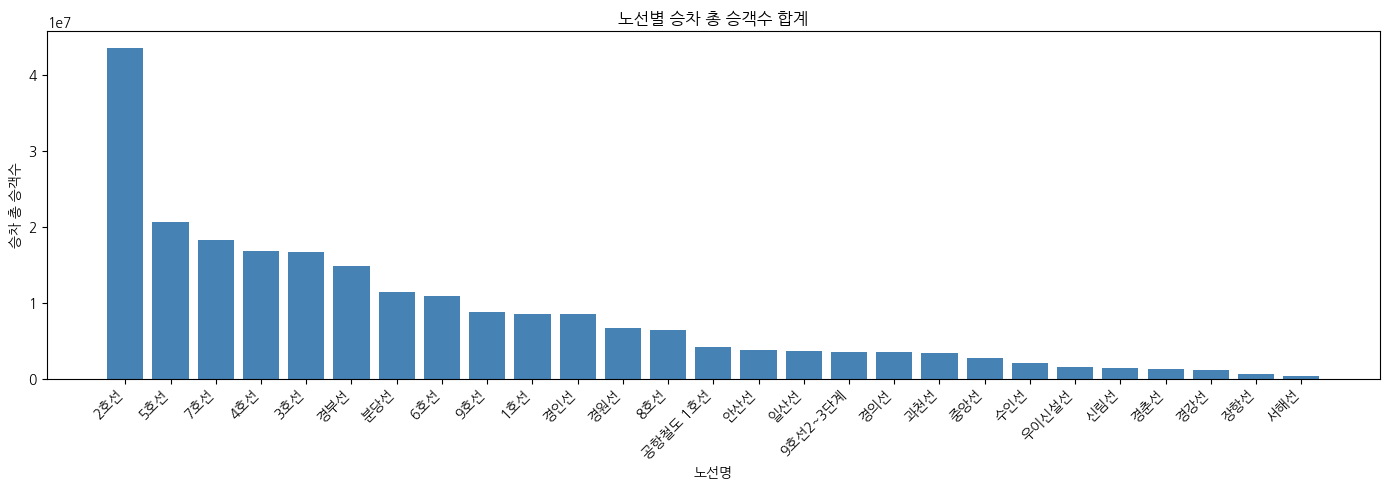

In [174]:
# 막대 그래프
plt.figure(figsize=(14, 5))
plt.bar(line_sum.index, line_sum.values, color='steelblue')
plt.title('노선별 승차 총 승객수 합계')
plt.xlabel('노선명')
plt.ylabel('승차 총 승객수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [187]:
# '승차총승객수' 기준 상위 10개 역 막대 그래프
top10_station = df.sort_values('승차총승객수', ascending=False).head(10)
top10_station # 중복된 데이터 강남, 홍대입구 존재함

,사용일자,노선명,역명,승차총승객수,하차총승객수,등록일자,승차총승객수_10,승하차총승객수,승하차총승객수합계,승차순위
118,2026-05-01,2호선,홍대입구,101927,115875,20260504,101937,-13948,217802,1
8668,2026-05-15,2호선,잠실(송파구청),100436,98646,20260518,100446,1790,199082,2
682,2026-05-02,2호선,홍대입구,100394,111108,20260505,100404,-10714,211502,3
8674,2026-05-15,2호선,강남,98157,96835,20260518,98167,1322,194992,4
13541,2026-05-22,1호선,서울역,97514,98036,20260525,97524,-522,195550,5
4342,2026-05-08,2호선,잠실(송파구청),97402,98062,20260511,97412,-660,195464,6
17330,2026-05-29,2호선,강남,96864,95651,20260601,96874,1213,192515,7
13571,2026-05-22,2호선,강남,96755,95209,20260525,96765,1546,191964,8
4336,2026-05-08,2호선,강남,96539,95218,20260511,96549,1321,191757,9
8643,2026-05-15,1호선,서울역,96164,95369,20260518,96174,795,191533,10


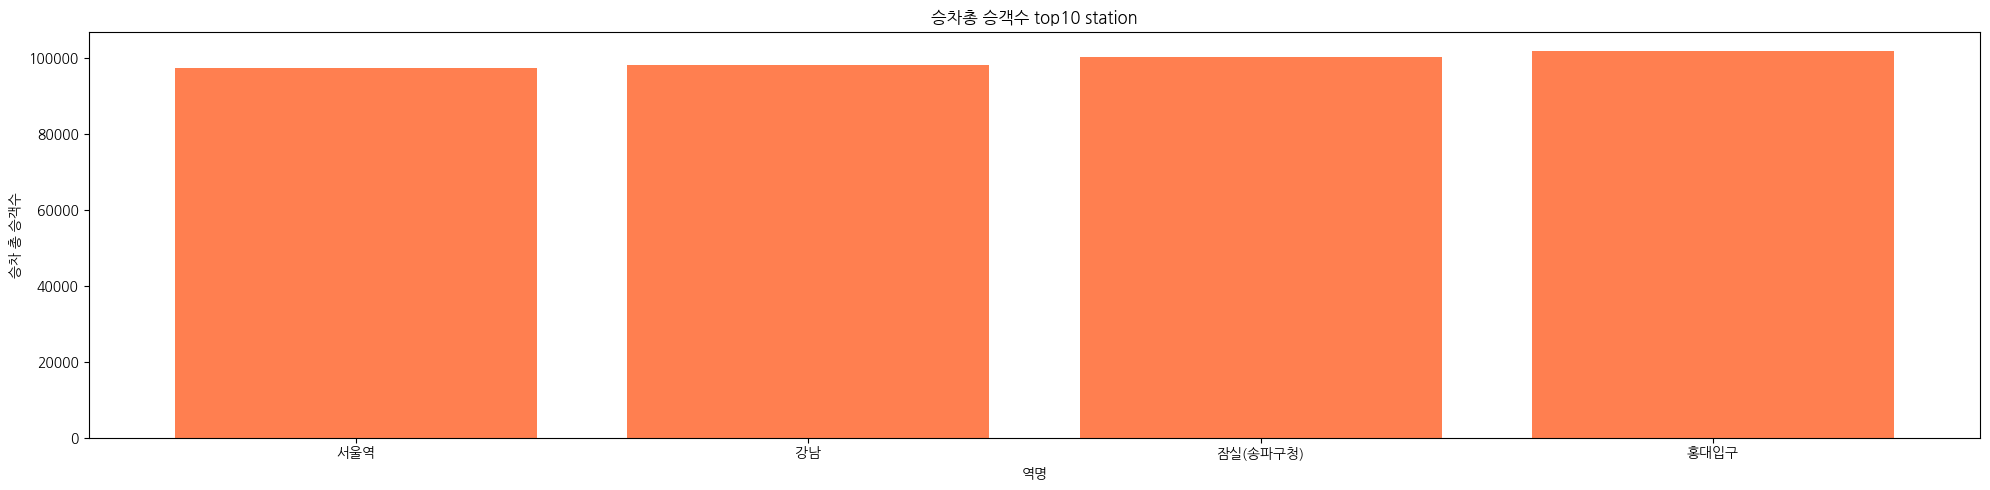

In [186]:
# 시각화
plt.figure(figsize=(20, 5))
plt.bar(top10_station['역명'], top10_station['승차총승객수'], color='coral')
plt.title('승차총 승객수 top10 station')
plt.xlabel('역명')
plt.ylabel('승차 총 승객수')
plt.gca().invert_xaxis()
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()